<a href="https://colab.research.google.com/github/satwikka/Automobile-Price-Prediction-using-Machine-Learning/blob/main/Satwika_Churn_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [4]:
df =pd.read_csv(r"/content/drive/MyDrive/DL/Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
df.shape

(10000, 14)

In [6]:
df.size

140000

In [9]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [10]:
df.index

RangeIndex(start=0, stop=10000, step=1)

In [11]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [12]:
df.axes

[RangeIndex(start=0, stop=10000, step=1),
 Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
        'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
        'IsActiveMember', 'EstimatedSalary', 'Exited'],
       dtype='object')]

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [14]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


EXPLORATORY DATA ANALYSIS
UNIVARIANT ANALYSIS

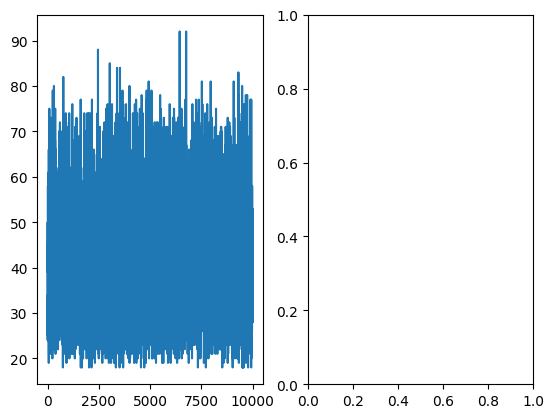

In [15]:
fig, ax = plt.subplots(1,2)
ax[0].plot(df["Age"])

In [16]:
def Univariate_Analysis_Of_Numerical_Columns(col):
  print(f"Univariate Analysis OF = {col}")

  print(f"Mean of {col} = {np.mean(df[col])}")
  print(f"Median of {col} = {np.median(df[col])}")
  print(f"Variance of {col} = {np.var(df[col])}")
  print(f"Standard Deviation of {col} = {np.std(df[col])}")


  fig, ax = plt.subplots(1,2)
  sns.histplot(x=df[col], ax=ax[0], color = "Black")
  sns.kdeplot(x=df[col], ax=ax[1], fill = True, color = "Purple")

Univariate Analysis OF = Age
Mean of Age = 38.9218
Median of Age = 37.0
Variance of Age = 109.9830847599996
Standard Deviation of Age = 10.487282048271592


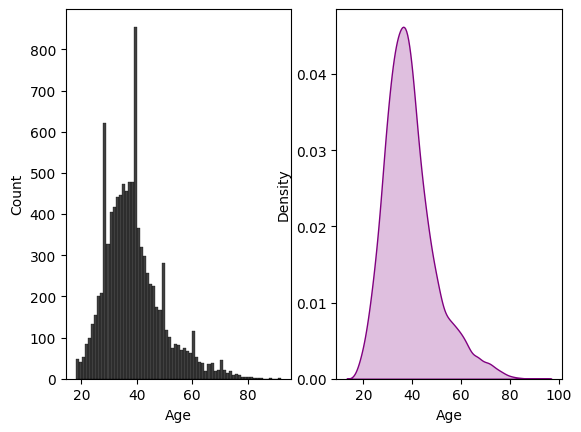

In [17]:
Univariate_Analysis_Of_Numerical_Columns("Age")

Univariate Analysis OF = CreditScore
Mean of CreditScore = 650.5288
Median of CreditScore = 652.0
Variance of CreditScore = 9340.925970560049
Standard Deviation of CreditScore = 96.64846595037113


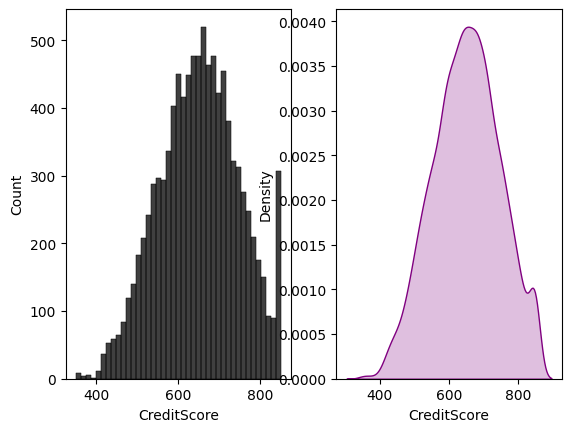

In [18]:
Univariate_Analysis_Of_Numerical_Columns("CreditScore")

Univariate Analysis OF = Tenure
Mean of Tenure = 5.0128
Median of Tenure = 5.0
Variance of Tenure = 8.36383616000014
Standard Deviation of Tenure = 2.8920297647154567


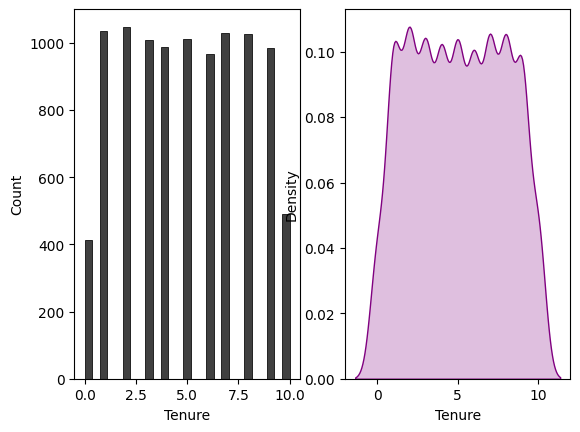

In [19]:
Univariate_Analysis_Of_Numerical_Columns("Tenure")

Univariate Analysis OF = Balance
Mean of Balance = 76485.889288
Median of Balance = 97198.54000000001
Variance of Balance = 3893046832.3731775
Standard Deviation of Balance = 62394.285254125454


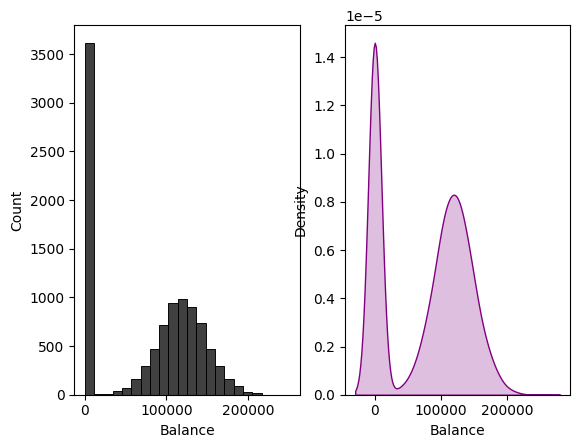

In [20]:
Univariate_Analysis_Of_Numerical_Columns("Balance")

Univariate Analysis OF = EstimatedSalary
Mean of EstimatedSalary = 100090.239881
Median of EstimatedSalary = 100193.915
Variance of EstimatedSalary = 3307126038.456105
Standard Deviation of EstimatedSalary = 57507.61722116562


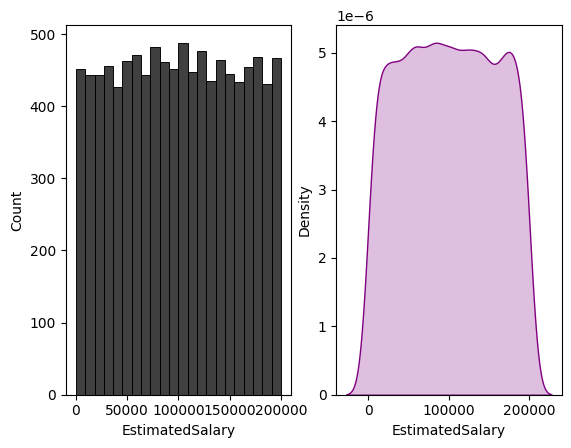

In [21]:
Univariate_Analysis_Of_Numerical_Columns("EstimatedSalary")

In [22]:
def Univariate_Analysis_Of_Categorical_Columns(col):
  print(f"Univariate Analysis OF = {col}")

  print(f"Number of Unique Values of a  {col} = {df[col].nunique()}")
  print(f"Unique Values of a {col} = {df[col].unique()}")
  print(f"Values Count of a {col} = {df[col].value_counts()}")

  sns.countplot(x = df[col], width=0.5, color = "Black")

Univariate Analysis OF = Tenure
Number of Unique Values of a  Tenure = 11
Unique Values of a Tenure = [ 2  1  8  7  4  6  3 10  5  9  0]
Values Count of a Tenure = Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64


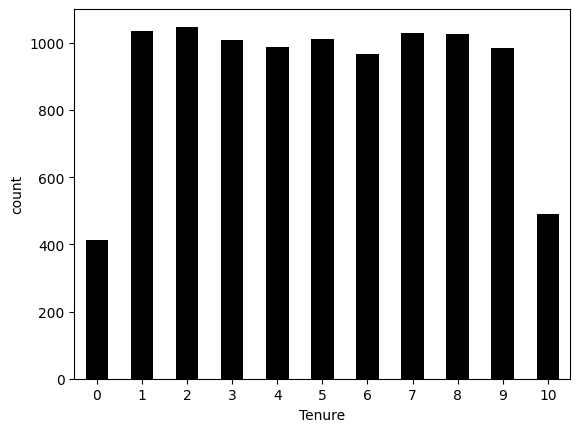

In [23]:
Univariate_Analysis_Of_Categorical_Columns("Tenure")

Univariate Analysis OF = NumOfProducts
Number of Unique Values of a  NumOfProducts = 4
Unique Values of a NumOfProducts = [1 3 2 4]
Values Count of a NumOfProducts = NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


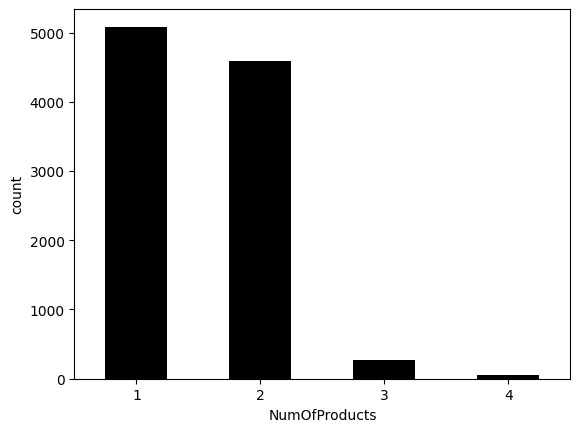

In [24]:
Univariate_Analysis_Of_Categorical_Columns("NumOfProducts")

Univariate Analysis OF = HasCrCard
Number of Unique Values of a  HasCrCard = 2
Unique Values of a HasCrCard = [1 0]
Values Count of a HasCrCard = HasCrCard
1    7055
0    2945
Name: count, dtype: int64


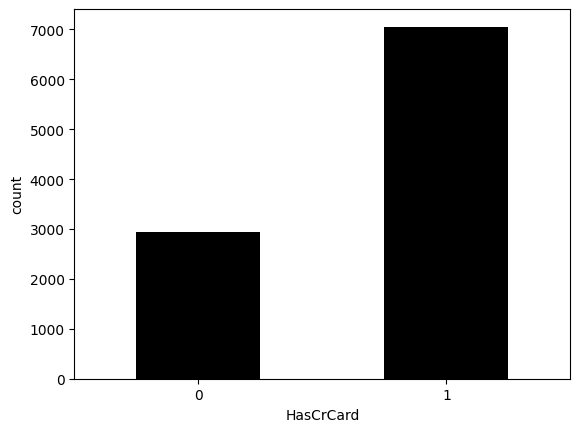

In [25]:
Univariate_Analysis_Of_Categorical_Columns("HasCrCard")

Univariate Analysis OF = Exited
Number of Unique Values of a  Exited = 2
Unique Values of a Exited = [1 0]
Values Count of a Exited = Exited
0    7963
1    2037
Name: count, dtype: int64


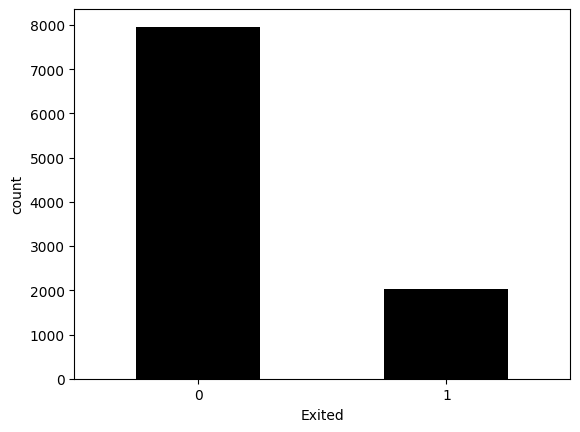

In [26]:
Univariate_Analysis_Of_Categorical_Columns("Exited")

Univariate Analysis OF = Geography
Number of Unique Values of a  Geography = 3
Unique Values of a Geography = ['France' 'Spain' 'Germany']
Values Count of a Geography = Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


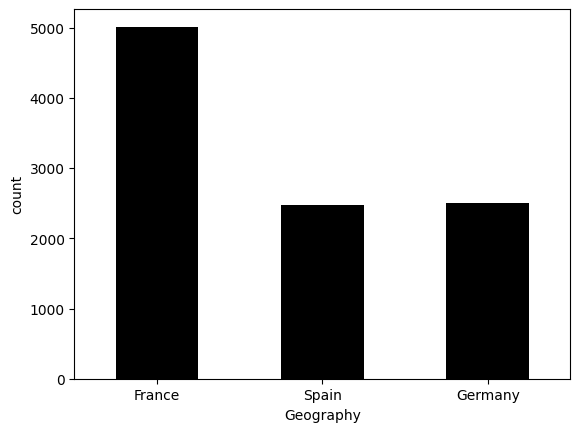

In [27]:
Univariate_Analysis_Of_Categorical_Columns("Geography")

In [28]:
def Bivariate_Analysis_Of_Numerical_Columns(col1,col2):
  print(f"Bivariate Analysis OF = {col1, col2}")

  sns.scatterplot(x = df[col1], y = df[col2], hue = df["Exited"])

Bivariate Analysis OF = ('Age', 'Balance')


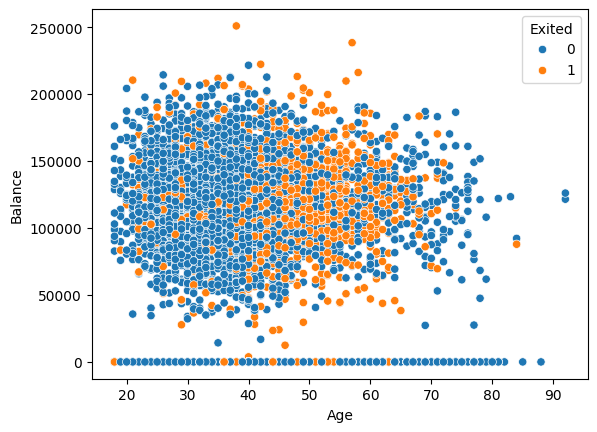

In [29]:
Bivariate_Analysis_Of_Numerical_Columns("Age", "Balance")

Bivariate Analysis OF = ('Age', 'CreditScore')


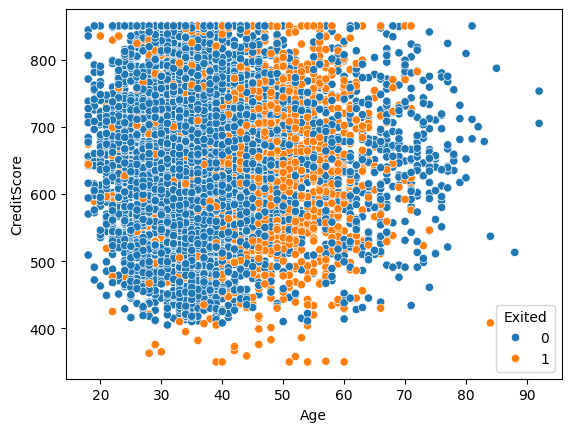

In [30]:
Bivariate_Analysis_Of_Numerical_Columns("Age", "CreditScore")

Bivariate Analysis OF = ('Age', 'EstimatedSalary')


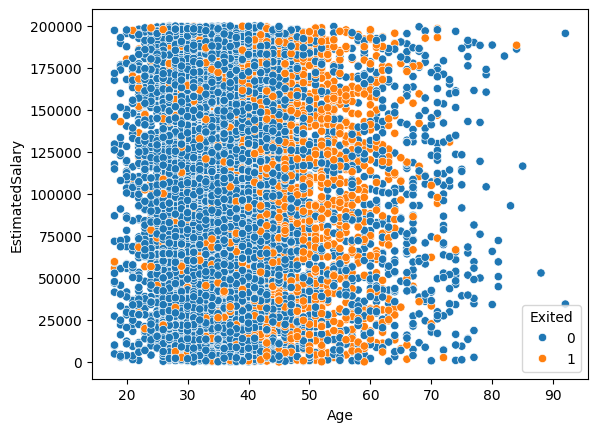

In [31]:
Bivariate_Analysis_Of_Numerical_Columns("Age", "EstimatedSalary")

Bivariate Analysis OF = ('Balance', 'EstimatedSalary')


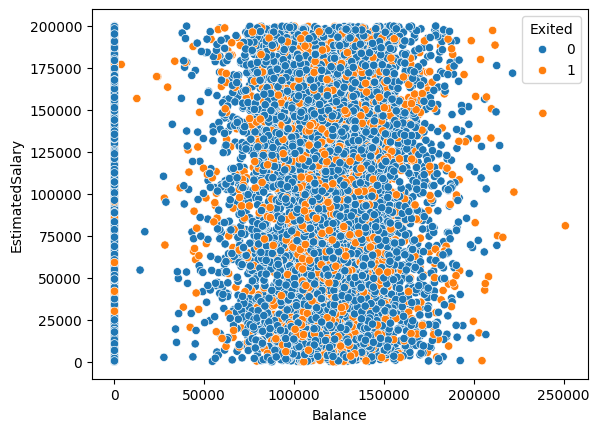

In [32]:
Bivariate_Analysis_Of_Numerical_Columns("Balance", "EstimatedSalary")

Bivariate Analysis OF = ('Tenure', 'EstimatedSalary')


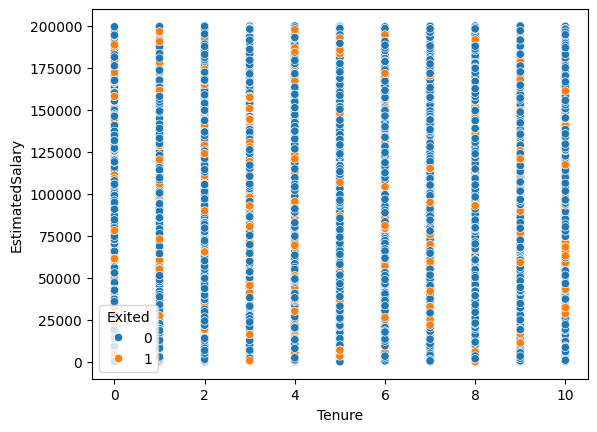

In [33]:
Bivariate_Analysis_Of_Numerical_Columns("Tenure", "EstimatedSalary")

In [34]:
def Bivariate_Analysis_Of_Categorical_Columns(col):
  print(f"Bivariate Analysis OF = {col}")


  sns.countplot(x = df[col], width=0.5, color = "Blue", hue = df["Exited"])

Bivariate Analysis OF = Geography


/tmp/ipykernel_524/2952471519.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Blue'` for the same effect.

  sns.countplot(x = df[col], width=0.5, color = "Blue", hue = df["Exited"])


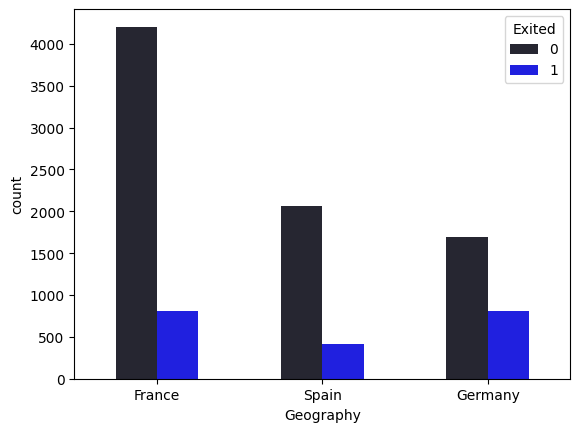

In [35]:
Bivariate_Analysis_Of_Categorical_Columns("Geography")

Bivariate Analysis OF = Gender


/tmp/ipykernel_524/2952471519.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Blue'` for the same effect.

  sns.countplot(x = df[col], width=0.5, color = "Blue", hue = df["Exited"])


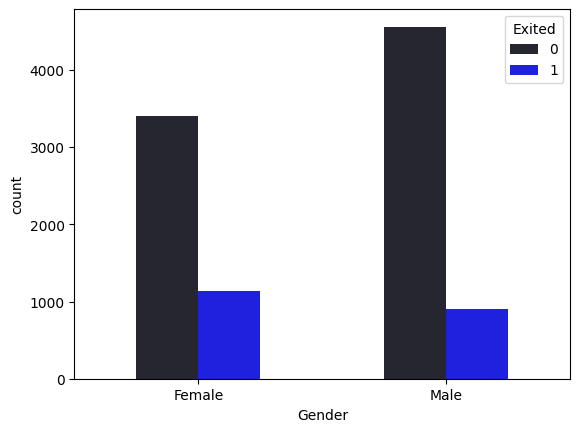

In [36]:
Bivariate_Analysis_Of_Categorical_Columns("Gender")

Bivariate Analysis OF = NumOfProducts


/tmp/ipykernel_524/2952471519.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Blue'` for the same effect.

  sns.countplot(x = df[col], width=0.5, color = "Blue", hue = df["Exited"])


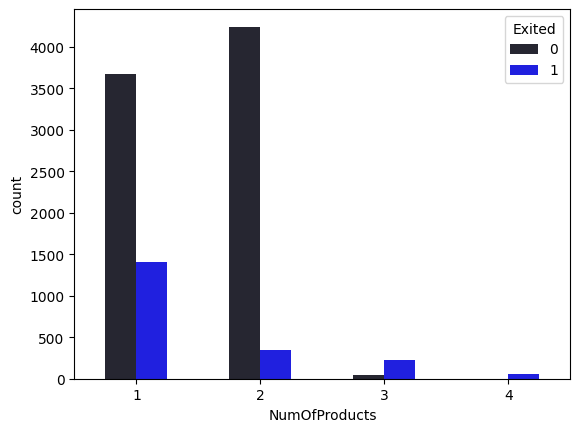

In [37]:
Bivariate_Analysis_Of_Categorical_Columns("NumOfProducts")

Bivariate Analysis OF = HasCrCard


/tmp/ipykernel_524/2952471519.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Blue'` for the same effect.

  sns.countplot(x = df[col], width=0.5, color = "Blue", hue = df["Exited"])


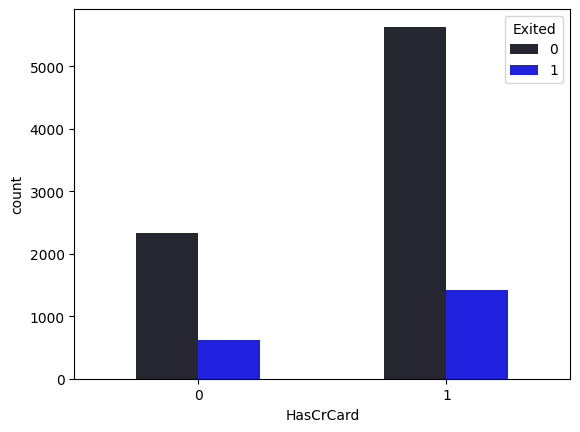

In [38]:
Bivariate_Analysis_Of_Categorical_Columns("HasCrCard")

Bivariate Analysis OF = IsActiveMember


/tmp/ipykernel_524/2952471519.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Blue'` for the same effect.

  sns.countplot(x = df[col], width=0.5, color = "Blue", hue = df["Exited"])


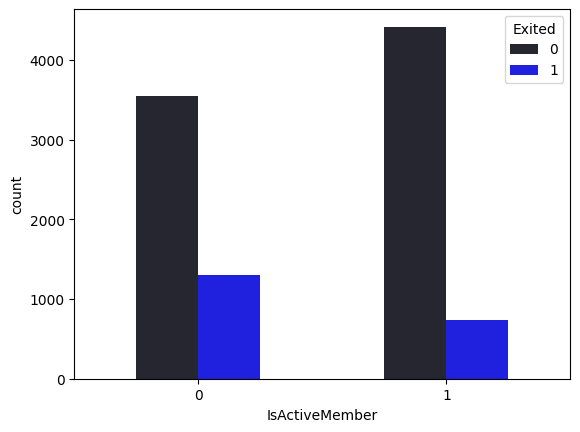

In [39]:
Bivariate_Analysis_Of_Categorical_Columns("IsActiveMember")

Bivariate Analysis OF = Tenure


/tmp/ipykernel_524/2952471519.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Blue'` for the same effect.

  sns.countplot(x = df[col], width=0.5, color = "Blue", hue = df["Exited"])


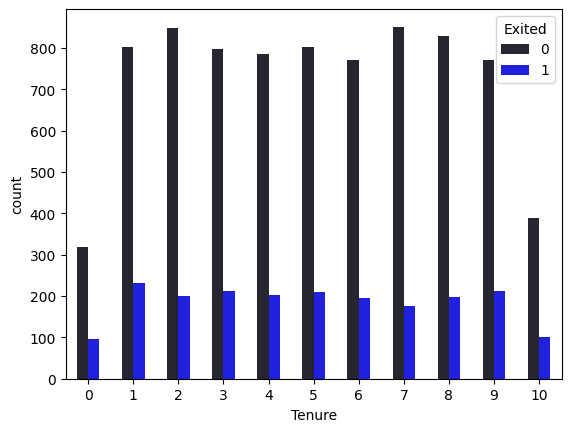

In [40]:
Bivariate_Analysis_Of_Categorical_Columns("Tenure")

ENCODING

In [41]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [42]:
df1=pd.concat([df, pd.get_dummies(df["Geography"])], axis=1).drop(["CustomerId", "Surname", "Geography", "RowNumber"], axis = 1)
df1

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,True,False,False
3,699,Female,39,1,0.00,2,0,0,93826.63,0,True,False,False
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,Male,39,5,0.00,2,1,0,96270.64,0,True,False,False
9996,516,Male,35,10,57369.61,1,1,1,101699.77,0,True,False,False
9997,709,Female,36,7,0.00,1,0,1,42085.58,1,True,False,False
9998,772,Male,42,3,75075.31,2,1,0,92888.52,1,False,True,False


In [43]:
df1.replace({"Male" : 0 , "Female" :1}, inplace = True)

/tmp/ipykernel_524/1353294047.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1.replace({"Male" : 0 , "Female" :1}, inplace = True)


In [44]:
df1.dtypes

,0
CreditScore,int64
Gender,int64
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64
Exited,int64


In [45]:
df1.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,1,42,8,159660.80,3,1,0,113931.57,1,True,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [46]:
df1.isna().sum()

,0
CreditScore,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0
Exited,0


In [47]:
df1.corr()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain
CreditScore,1.000000,0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,-0.008928,0.005538,0.004780
Gender,0.002857,1.000000,0.027544,-0.014733,-0.012087,0.021859,-0.005766,-0.022544,0.008112,0.106512,-0.006772,0.024628,-0.016889
Age,-0.003965,0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,-0.039208,0.046897,-0.001685
Tenure,0.000842,-0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.002848,-0.000567,0.003868
Balance,0.006268,-0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,-0.231329,0.401110,-0.134892
NumOfProducts,0.012238,0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,0.001230,-0.010419,0.009039
HasCrCard,-0.005458,-0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.002467,0.010577,-0.013480
IsActiveMember,0.025651,-0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,0.003317,-0.020486,0.016732
EstimatedSalary,-0.001384,0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,-0.003332,0.010297,-0.006482
Exited,-0.027094,0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,-0.104955,0.173488,-0.052667


<Axes: >

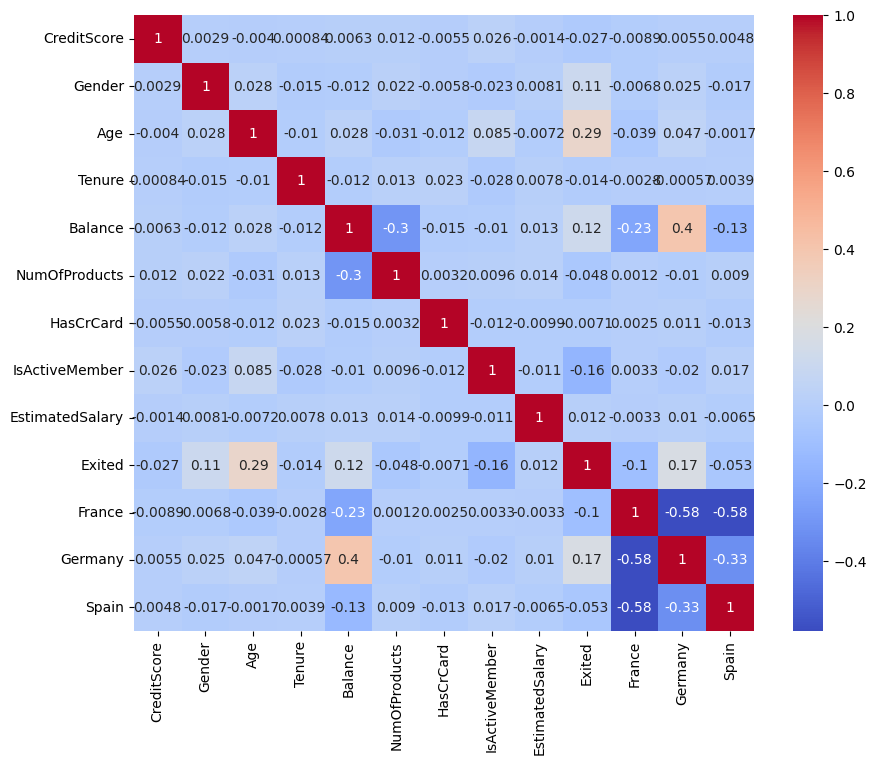

In [48]:
plt.figure(figsize = (10,8))
sns.heatmap(df1.corr(), annot = True, cmap = "coolwarm")

<Axes: >

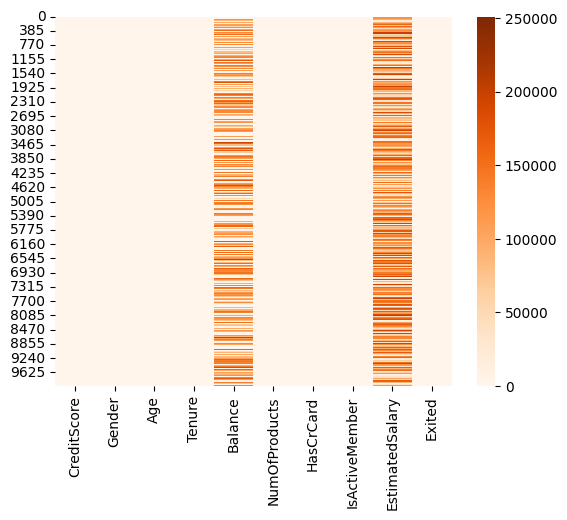

In [49]:
sns.heatmap(df1.iloc[:,:10], cmap = "Oranges")

In [50]:
df1.iloc[:,:9].corr()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
CreditScore,1.000000,0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384
Gender,0.002857,1.000000,0.027544,-0.014733,-0.012087,0.021859,-0.005766,-0.022544,0.008112
Age,-0.003965,0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201
Tenure,0.000842,-0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784
Balance,0.006268,-0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797
NumOfProducts,0.012238,0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204
HasCrCard,-0.005458,-0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933
IsActiveMember,0.025651,-0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421
EstimatedSalary,-0.001384,0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000


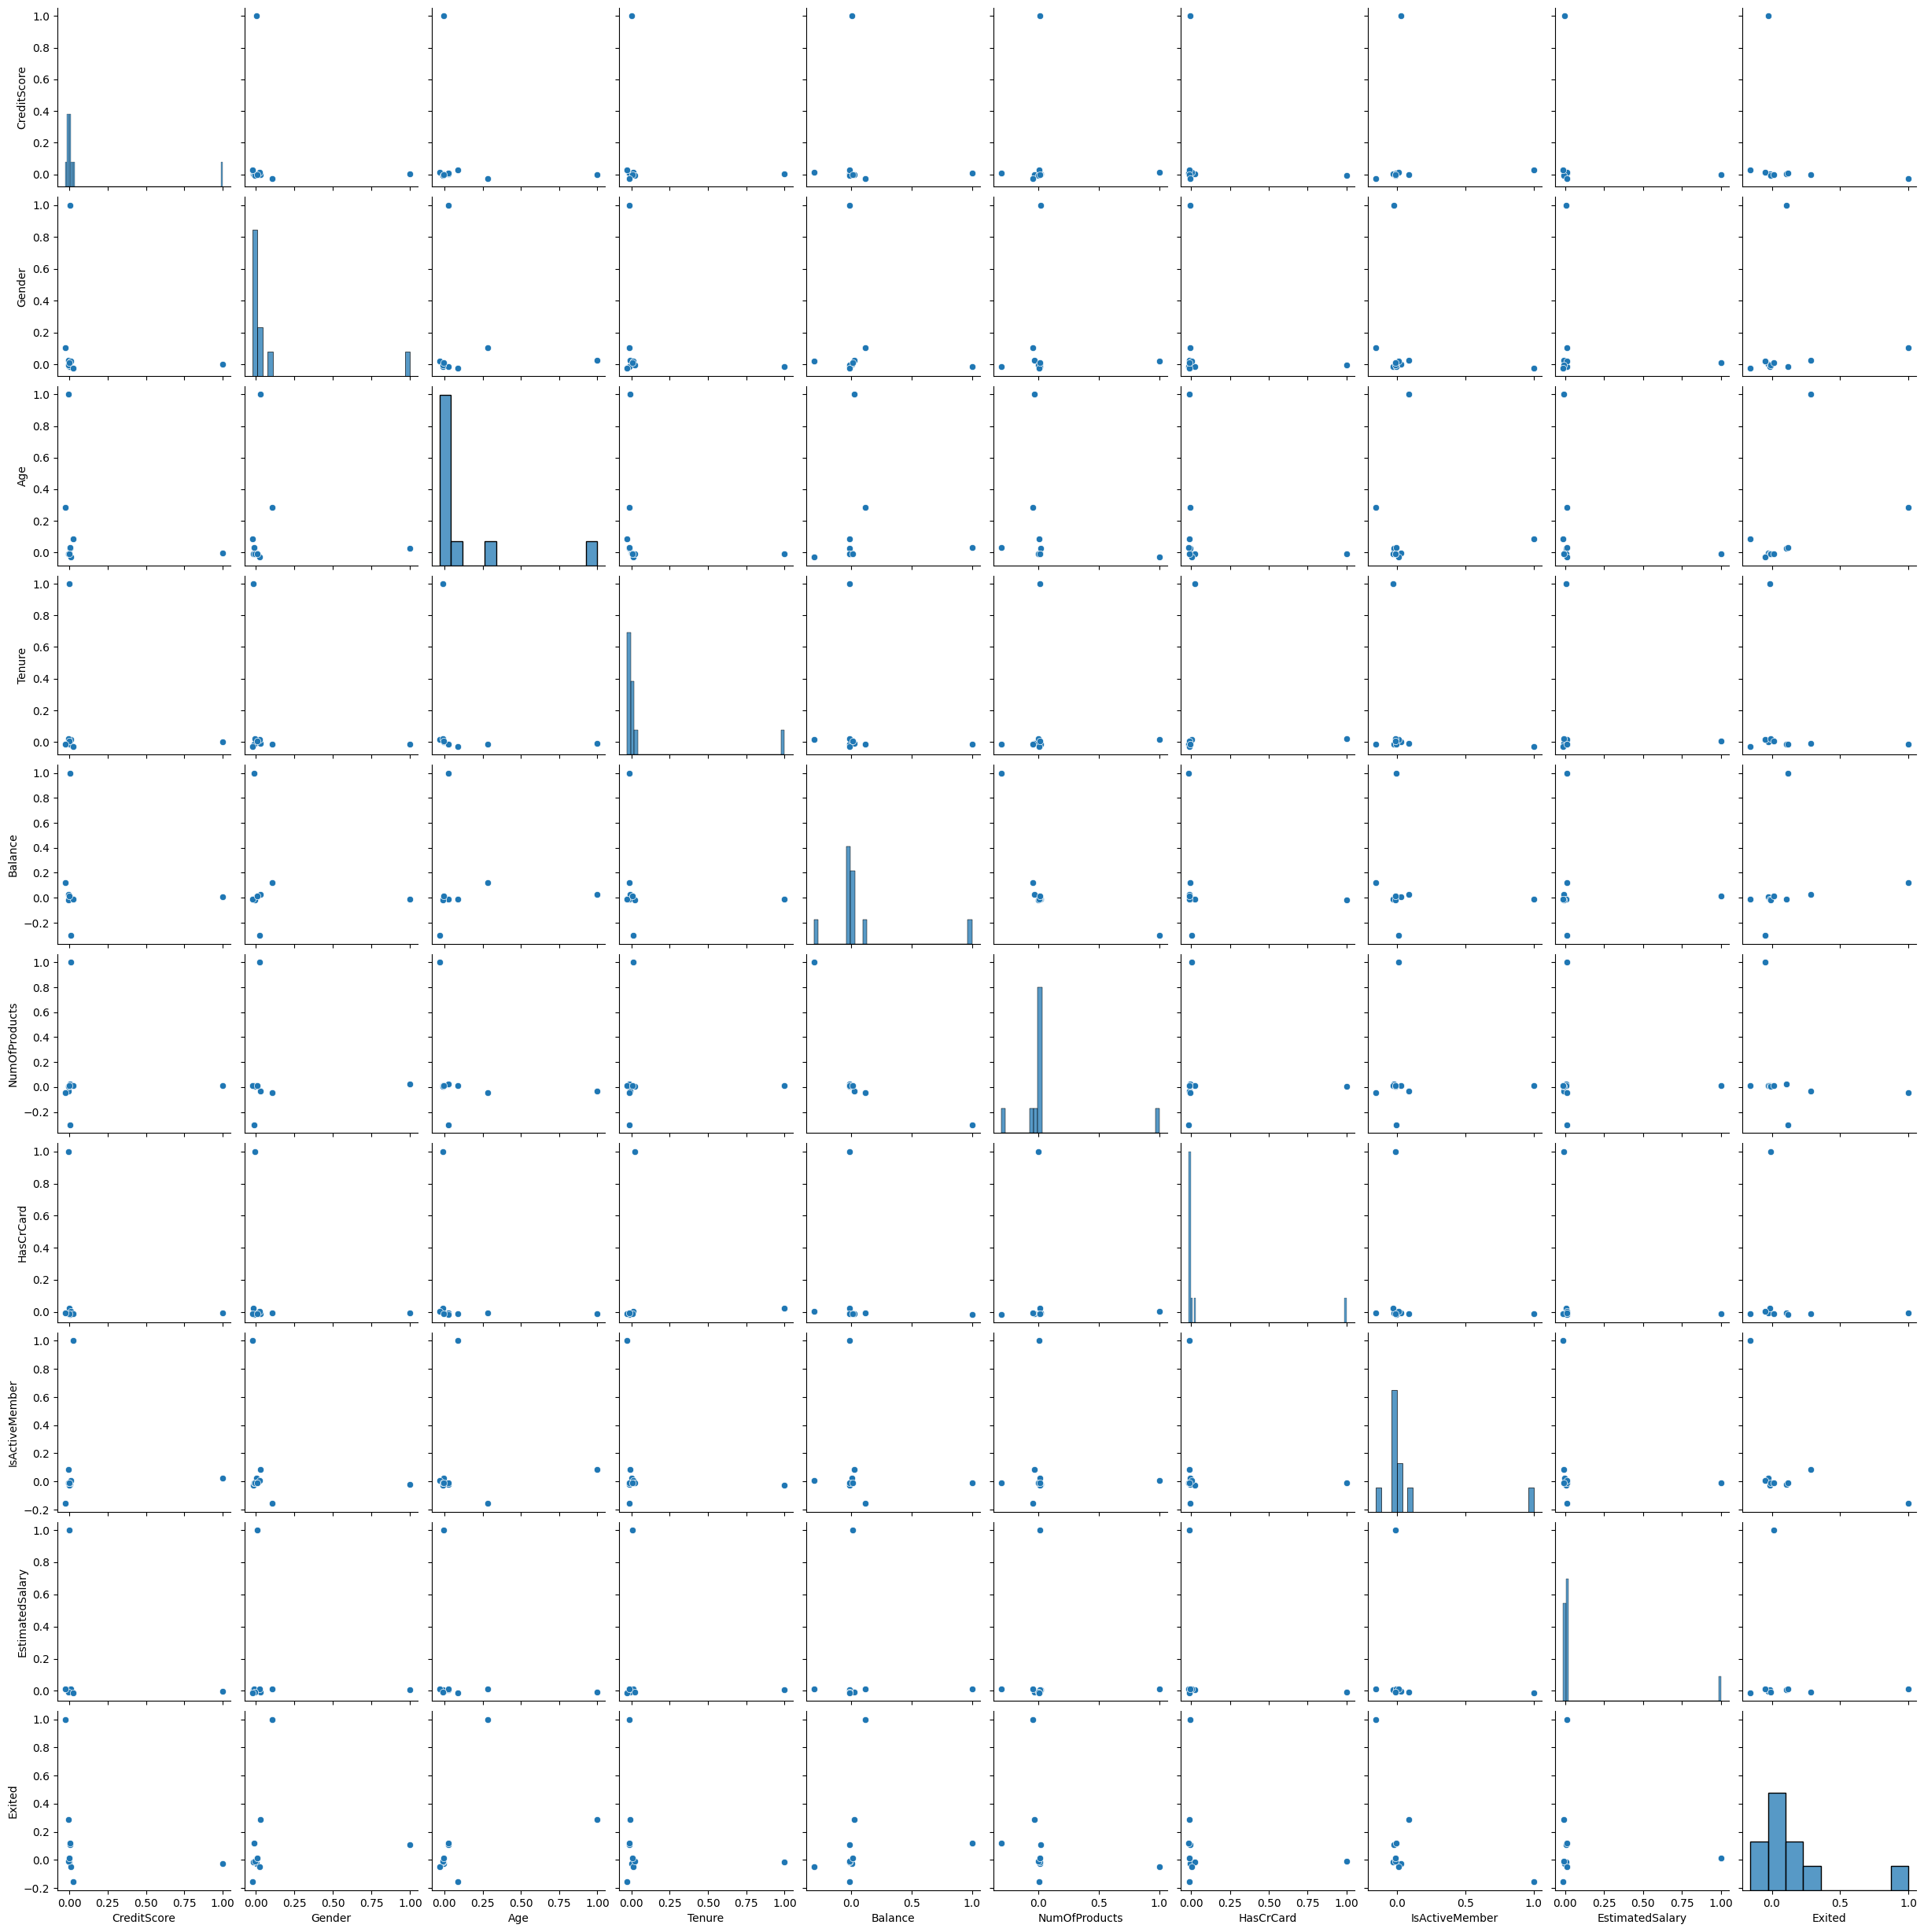

In [51]:
sns.pairplot(df1.iloc[:,:10].corr())

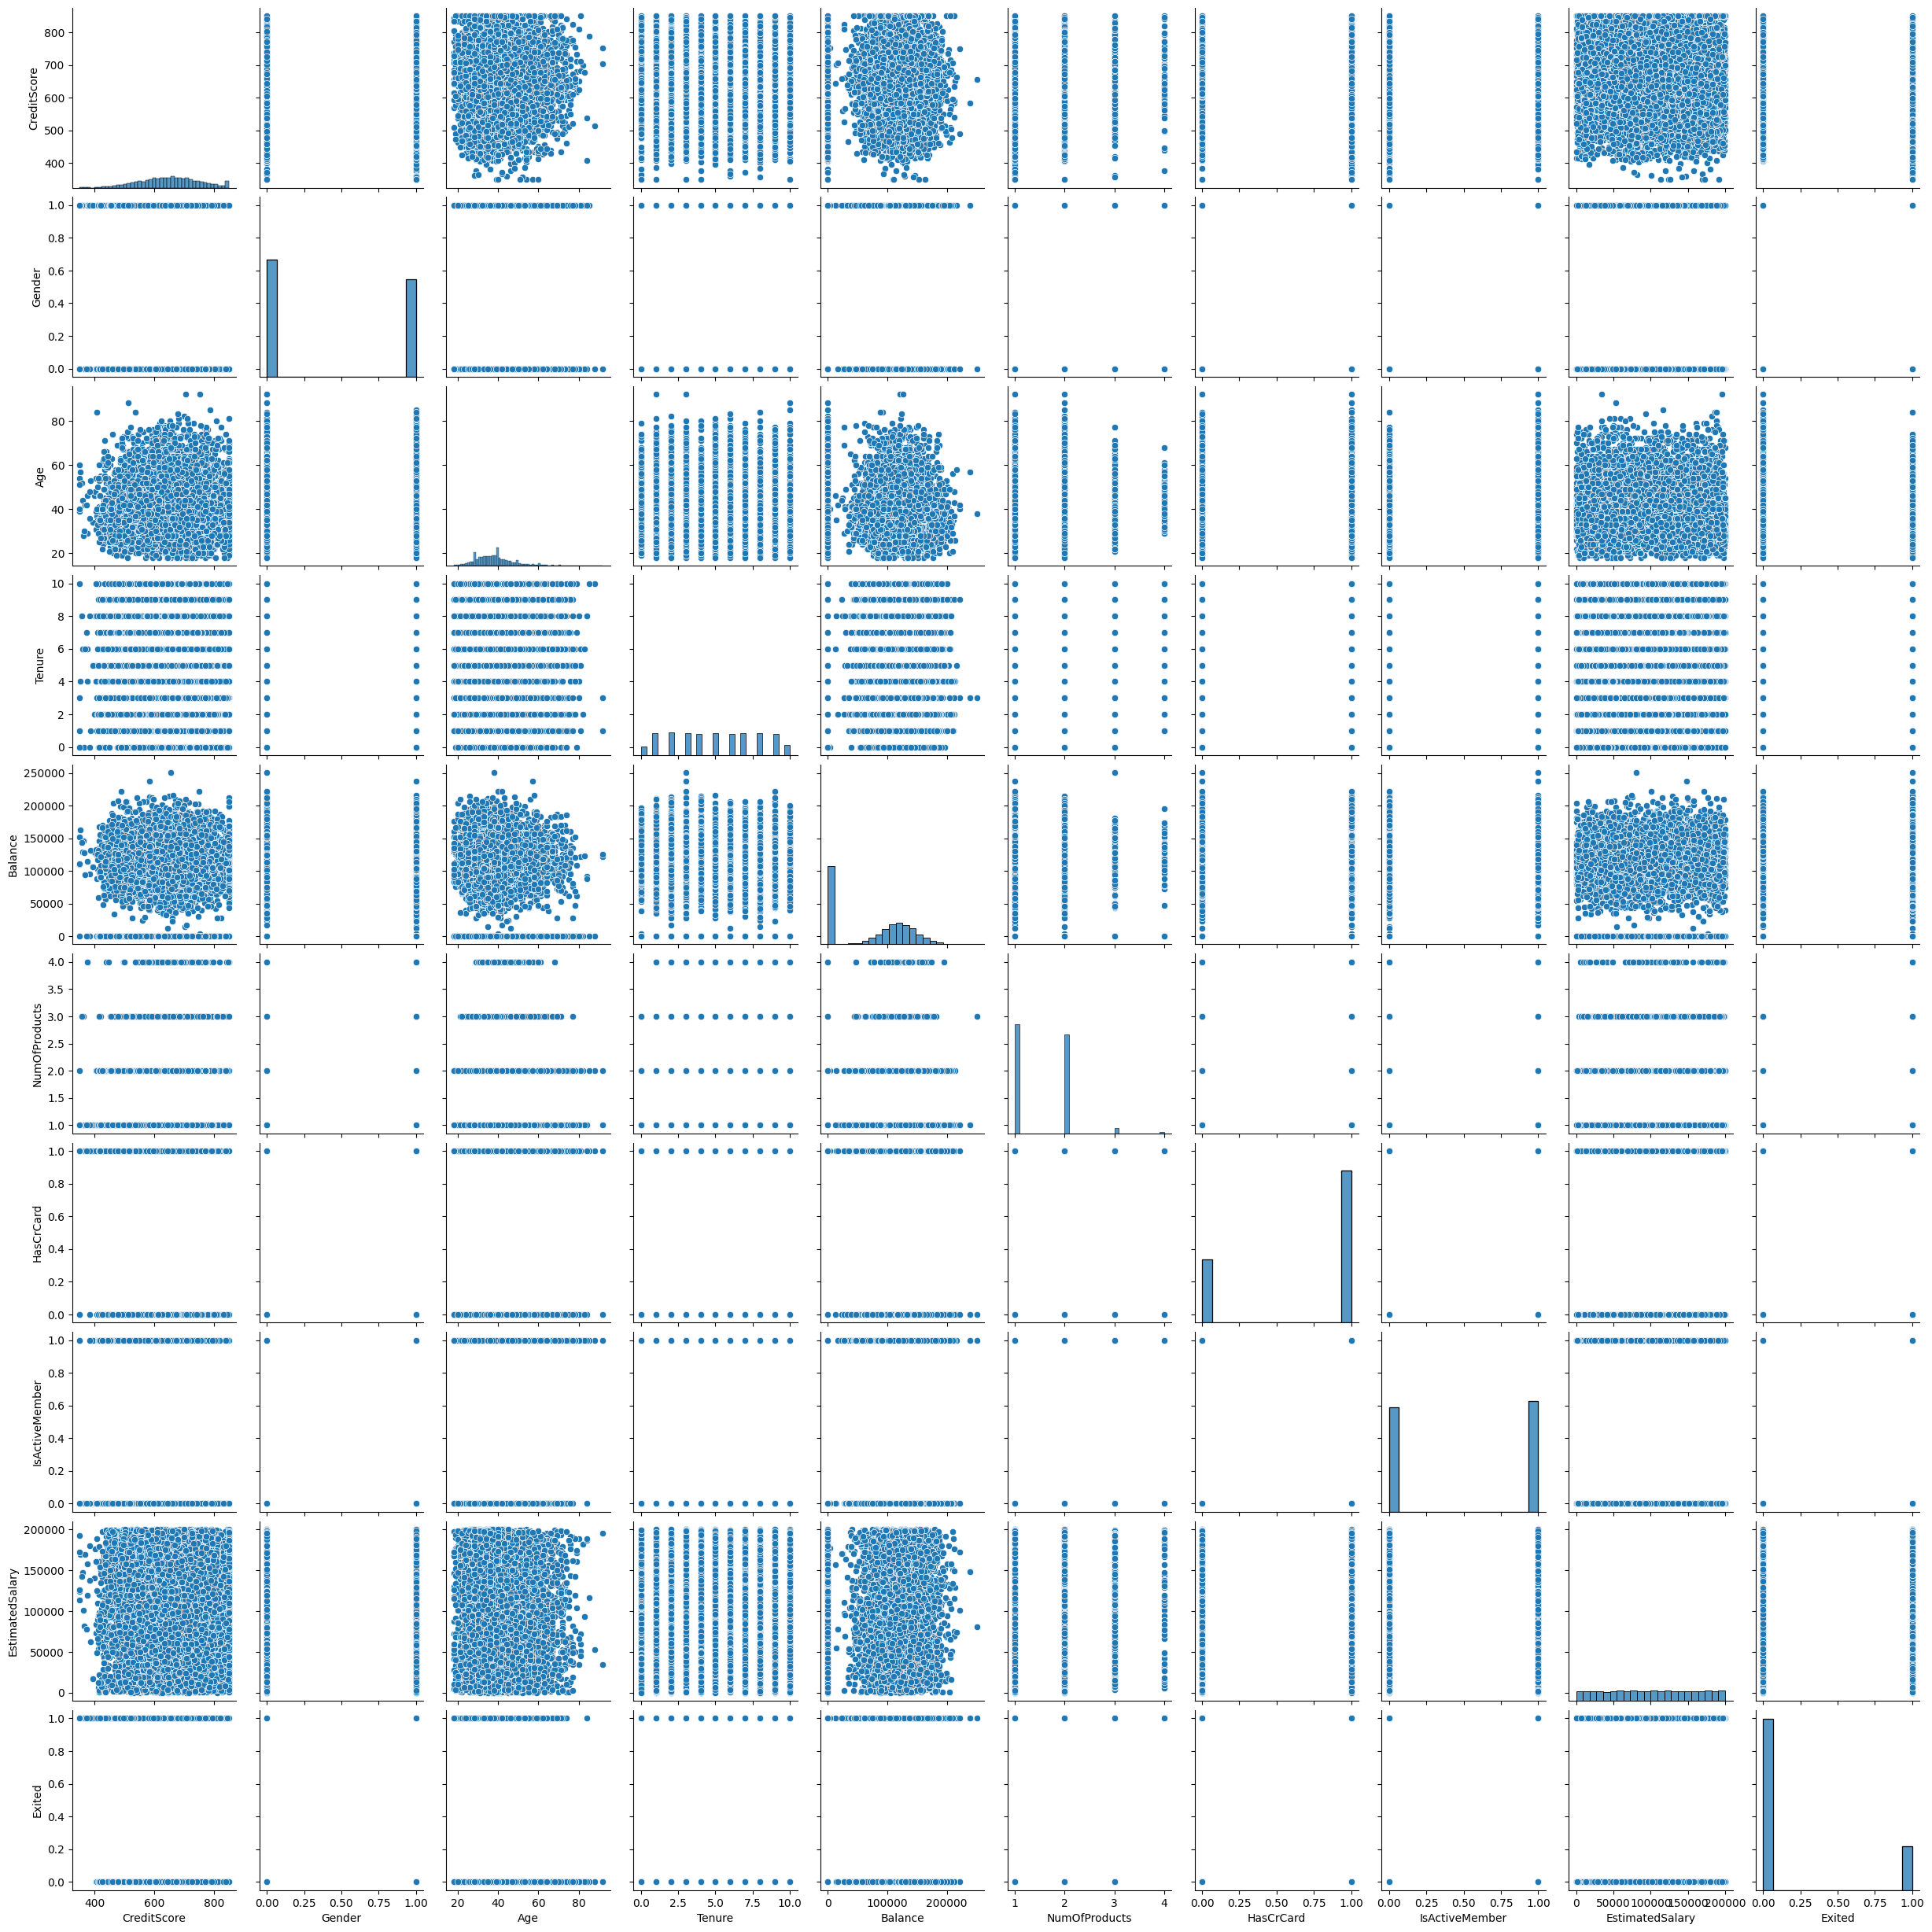

In [52]:
sns.pairplot(df1.iloc[:,:10])

In [53]:
df1.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'France',
       'Germany', 'Spain'],
      dtype='object')

Independant Features : ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'France', 'Germany', 'Spain']

Target Column : 'Exited

In [54]:
x = df1[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'France', 'Germany', 'Spain']]
y = df1['Exited']

In [55]:
x.shape

(10000, 12)

In [56]:
x.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain
0,619,1,42,2,0.00,1,1,1,101348.88,True,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,False,False,True
2,502,1,42,8,159660.80,3,1,0,113931.57,True,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,False,False,True


In [57]:
numerical_columns = ['CreditScore','Age', 'Balance','EstimatedSalary']

In [58]:
x.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain
0,619,1,42,2,0.00,1,1,1,101348.88,True,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,False,False,True
2,502,1,42,8,159660.80,3,1,0,113931.57,True,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,False,False,True


In [59]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


Train Test Split

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size = 0.2)

In [62]:
xtrain.shape

(8000, 12)

In [63]:
xtest.shape

(2000, 12)

In [66]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(xtrain, ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [67]:
y_pred = model.predict(xtest)

In [69]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(ytest, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.793


In [71]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(ytest, y_pred))
print(classification_report(ytest, y_pred))

[[1566   33]
 [ 381   20]]
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1599
           1       0.38      0.05      0.09       401

    accuracy                           0.79      2000
   macro avg       0.59      0.51      0.49      2000
weighted avg       0.72      0.79      0.72      2000

